# Baseline Models for Team Rho

#### Team Rho Capstone Project

##### *Brendan Collari and Casey Brookshier*
**Author:** Brendan Collari & J. Casey Brookshier  
**Date:** July 31, 2026

### Objective:
Establish a benchmark model to determine how well the engineered Google Trends features predict future psychiatric admission rates before testing more advanced models.



In [2]:
# establish paths
from pathlib import Path

current_dir = Path.cwd()

for path in [current_dir] + list(current_dir.parents):
    if (
        (path / "Data").is_dir()
        and (path / "Notebooks").is_dir()
        and (path / "requirements.txt").is_file()
    ):
        PROJECT_ROOT = path
        break
else:
    raise FileNotFoundError(
        "Could not locate the Team-Rho-Capstone-Project repository root."
    )

# repository directories
DATA_DIR = (
    PROJECT_ROOT
    / "Data"
    / "processed"
    / "Engineered_Data_v2"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "figures"
    / "baseline"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# input files
TRAIN_FILE = (
    DATA_DIR
    / "team_rho_train_preprocessed_engineered_v2.csv"
)

TEST_FILE = (
    DATA_DIR
    / "team_rho_test_preprocessed_engineered_v2.csv"
)

# verify paths
print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Figure directory:", FIGURE_DIR)
print("Training file:", TRAIN_FILE)
print("Testing file:", TEST_FILE)

if not TRAIN_FILE.exists():
    raise FileNotFoundError(
        f"Training file not found:\n{TRAIN_FILE}"
    )

if not TEST_FILE.exists():
    raise FileNotFoundError(
        f"Testing file not found:\n{TEST_FILE}"
    )

print("\nRepository paths verified successfully.")

Project root: /Users/brendan/Documents/DSE6214/Team-Rho-Capstone-Project
Data directory: /Users/brendan/Documents/DSE6214/Team-Rho-Capstone-Project/Data/processed/Engineered_Data_v2
Figure directory: /Users/brendan/Documents/DSE6214/Team-Rho-Capstone-Project/figures/baseline
Training file: /Users/brendan/Documents/DSE6214/Team-Rho-Capstone-Project/Data/processed/Engineered_Data_v2/team_rho_train_preprocessed_engineered_v2.csv
Testing file: /Users/brendan/Documents/DSE6214/Team-Rho-Capstone-Project/Data/processed/Engineered_Data_v2/team_rho_test_preprocessed_engineered_v2.csv

Repository paths verified successfully.


In [3]:
# imports - load engineered train/test data

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import norm

# Disable optional pandas compiled dependencies.
os.environ["PANDAS_USE_BOTTLENECK"] = "0"
os.environ["PANDAS_USE_NUMEXPR"] = "0"

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

train = pd.read_csv(TRAIN_FILE)
test = pd.read_csv(TEST_FILE)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nColumns:")
print(train.columns.tolist())

train.head()

Train shape: (227, 9)
Test shape: (133, 9)

Columns:
['State', 'Year', 'admission_rate_per_100k', 'admission_rate_lag2', 'neighbor_admission_rate_lag1', 'search_PC1', 'search_PC2', 'search_PC3', 'log_state_population']


,State,Year,admission_rate_per_100k,admission_rate_lag2,neighbor_admission_rate_lag1,search_PC1,search_PC2,search_PC3,log_state_population
0,Alaska,2017,303.650691,297.929391,394.821026,-4.362284,-0.868199,-0.377299,13.515733
1,Alaska,2018,319.023002,289.533044,407.012291,-4.243584,-0.623294,-0.459835,13.509833
2,Alaska,2019,333.968100,303.650691,408.686371,-3.918116,-0.194698,-1.192840,13.505723
3,Alaska,2020,348.761827,319.023002,410.772841,-3.797099,-0.049901,-1.278749,13.502385
4,Arizona,2016,205.910436,223.530133,340.205703,0.978794,-0.049951,1.845417,15.753499


In [4]:
# define target and predictors


target = "admission_rate_per_100k"

X_train = train.drop(
    columns=[target]
)

y_train = train[target]

X_test = test.drop(
    columns=[target]
)

y_test = test[target]

# remove Year from model predictors.
# temporal ordering is kept separately for validation.
X_train = X_train.drop(
    columns=["Year"]
)

X_test = X_test.drop(
    columns=["Year"]
)

# state fixed effects
X_train = pd.get_dummies(
    X_train,
    columns=["State"],
    drop_first=True,
    dtype=float
)

X_test = pd.get_dummies(
    X_test,
    columns=["State"],
    drop_first=True,
    dtype=float
)

# ensure identical feature columns
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print("Final feature count:", X_train.shape[1])
print("\nPredictors:")
print(X_train.columns.tolist())

Final feature count: 51

Predictors:
['admission_rate_lag2', 'neighbor_admission_rate_lag1', 'search_PC1', 'search_PC2', 'search_PC3', 'log_state_population', 'State_Arizona', 'State_Arkansas', 'State_California', 'State_Colorado', 'State_Delaware', 'State_Florida', 'State_Georgia', 'State_Hawaii', 'State_Illinois', 'State_Indiana', 'State_Iowa', 'State_Kansas', 'State_Kentucky', 'State_Louisiana', 'State_Maine', 'State_Maryland', 'State_Massachusetts', 'State_Michigan', 'State_Minnesota', 'State_Mississippi', 'State_Missouri', 'State_Montana', 'State_Nebraska', 'State_Nevada', 'State_New Jersey', 'State_New Mexico', 'State_New York', 'State_North Carolina', 'State_North Dakota', 'State_Ohio', 'State_Oklahoma', 'State_Oregon', 'State_Pennsylvania', 'State_Rhode Island', 'State_South Carolina', 'State_South Dakota', 'State_Tennessee', 'State_Texas', 'State_Utah', 'State_Vermont', 'State_Virginia', 'State_Washington', 'State_West Virginia', 'State_Wisconsin', 'State_Wyoming']


In [5]:
# evaluation helper functions


def rmse(y, pred):
    return np.sqrt(
        np.mean(
            (y - pred) ** 2
        )
    )


def mae(y, pred):
    return np.mean(
        np.abs(y - pred)
    )


def r2_score_numpy(y, pred):
    ss_res = np.sum(
        (y - pred) ** 2
    )

    ss_tot = np.sum(
        (y - y.mean()) ** 2
    )

    return 1 - (
        ss_res / ss_tot
    )


def durbin_watson_numpy(residuals):
    diff = np.diff(residuals)

    return (
        np.sum(diff ** 2)
        /
        np.sum(residuals ** 2)
    )

In [6]:
# NumPy ordinary least squares


def fit_linear_model(X, y):

    X_matrix = np.column_stack(
        [
            np.ones(len(X)),
            X.values
        ]
    )

    beta = np.linalg.lstsq(
        X_matrix,
        y.values,
        rcond=None
    )[0]

    return beta


def predict_linear_model(X, beta):

    X_matrix = np.column_stack(
        [
            np.ones(len(X)),
            X.values
        ]
    )

    return X_matrix @ beta

In [7]:
# initial baseline model fit


beta = fit_linear_model(
    X_train,
    y_train
)

print("Baseline model fitted.")
print("Number of coefficients:", len(beta))

Baseline model fitted.
Number of coefficients: 52


In [8]:
# chronological 5-fold expanding-window CV


# sort observations chronologically
train = train.sort_values(
    ["Year", "State"]
).reset_index(drop=True)

# rebuild target and predictors after chronological sorting
X_train = train.drop(
    columns=[target, "Year"]
)

y_train = train[target]

# state fixed effects
X_train = pd.get_dummies(
    X_train,
    columns=["State"],
    drop_first=True,
    dtype=float
)

# build test predictors
X_test = test.drop(
    columns=[target, "Year"]
)

X_test = pd.get_dummies(
    X_test,
    columns=["State"],
    drop_first=True,
    dtype=float
)

# ensure identical columns
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print(
    "Chronologically ordered:",
    train["Year"].is_monotonic_increasing
)

print("Training observations:", len(X_train))
print("Predictors:", X_train.shape[1])

Chronologically ordered: True
Training observations: 227
Predictors: 51


In [9]:
# time-series cross-validation


def time_series_cv(X, y, splits=5):

    validation_size = 30

    initial_train_size = (
        len(X) -
        splits * validation_size
    )

    if initial_train_size <= X.shape[1]:
        raise ValueError(
            "Initial training set is not large enough "
            "for the number of predictors."
        )

    scores = []

    for i in range(splits):

        train_end = (
            initial_train_size
            + i * validation_size
        )

        validation_end = (
            train_end
            + validation_size
        )

        X_tr = X.iloc[:train_end]
        y_tr = y.iloc[:train_end]

        X_val = X.iloc[
            train_end:validation_end
        ]

        y_val = y.iloc[
            train_end:validation_end
        ]

        if len(X_tr) <= X_tr.shape[1]:
            raise ValueError(
                f"Fold {i + 1}: "
                f"{len(X_tr)} observations, "
                f"{X_tr.shape[1]} predictors."
            )

        fold_beta = fit_linear_model(
            X_tr,
            y_tr
        )

        pred = predict_linear_model(
            X_val,
            fold_beta
        )

        scores.append(
            rmse(
                y_val.values,
                pred
            )
        )

    return np.array(scores)


cv_rmse = time_series_cv(
    X_train,
    y_train,
    splits=5
)

print("CV RMSE by fold:")
print(cv_rmse)

print(
    f"\nMean CV RMSE: "
    f"{cv_rmse.mean():.2f} ± "
    f"{cv_rmse.std():.2f}"
)

CV RMSE by fold:
[174.21250904  29.87966013  67.21914215  46.28540211  46.80993154]

Mean CV RMSE: 72.88 ± 52.03


In [10]:
#fit baseline and generate predictions


beta = fit_linear_model(
    X_train,
    y_train
)

train_pred = predict_linear_model(
    X_train,
    beta
)

test_pred = predict_linear_model(
    X_test,
    beta
)

print("Predictions generated.")
print("Training predictions:", len(train_pred))
print("Testing predictions:", len(test_pred))

Predictions generated.
Training predictions: 227
Testing predictions: 133


In [11]:
# model evaluation


def evaluate(name, y, pred):

    print("\n" + name)
    print("--------------------")

    print(
        f"RMSE: {rmse(y.values, pred):.3f}"
    )

    print(
        f"MAE : {mae(y.values, pred):.3f}"
    )

    print(
        f"R²  : {r2_score_numpy(y.values, pred):.3f}"
    )


evaluate(
    "Training",
    y_train,
    train_pred
)

evaluate(
    "Testing",
    y_test,
    test_pred
)

train_r2 = r2_score_numpy(
    y_train.values,
    train_pred
)

test_r2 = r2_score_numpy(
    y_test.values,
    test_pred
)

print("\nOverfitting Check")
print("--------------------")

print(
    "Training R²:",
    train_r2
)

print(
    "Testing R²:",
    test_r2
)


Training
--------------------
RMSE: 38.035
MAE : 23.614
R²  : 0.936

Testing
--------------------
RMSE: 53.983
MAE : 41.966
R²  : 0.829

Overfitting Check
--------------------
Training R²: 0.9361847980065395
Testing R²: 0.8293610296555374


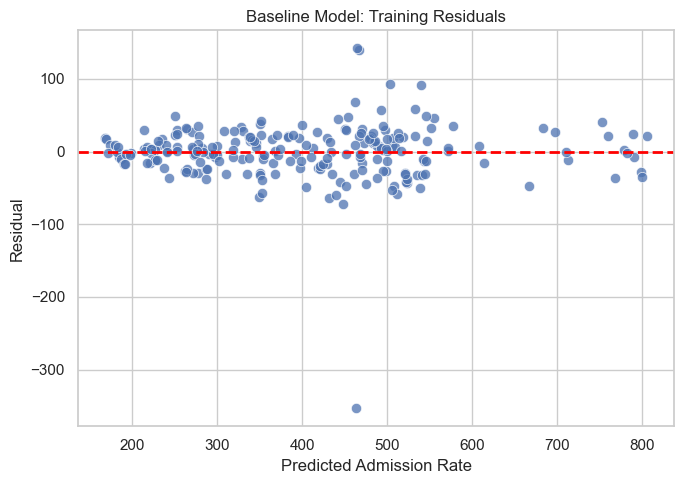

In [12]:
# train residual diagnostics


residuals = (
    y_train.values
    - train_pred
)

plt.figure(
    figsize=(7, 5)
)

sns.scatterplot(
    x=train_pred,
    y=residuals,
    s=55,
    alpha=0.75
)

plt.axhline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Admission Rate")
plt.ylabel("Residual")
plt.title("Baseline Model: Training Residuals")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "baseline_training_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

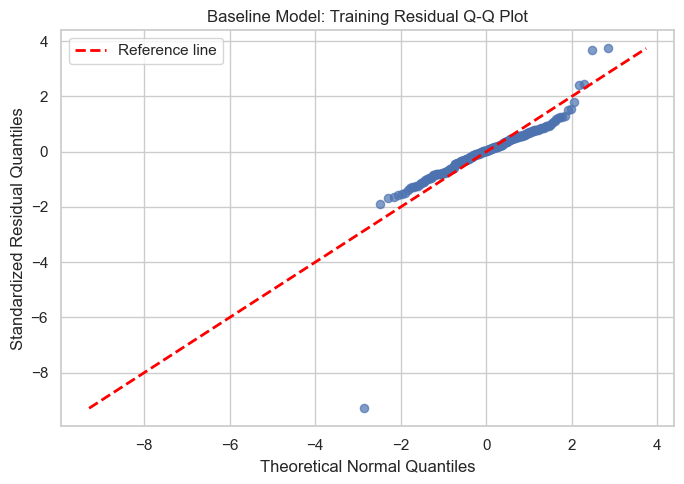

In [13]:
#training residual Q-Q plot


sorted_residuals = np.sort(
    residuals
)

n = len(sorted_residuals)

probabilities = (
    np.arange(1, n + 1) - 0.5
) / n

#  SciPy rather than np.erfinv for portability
theoretical_quantiles = norm.ppf(
    probabilities
)

standardized_residuals = (
    sorted_residuals
    - np.mean(sorted_residuals)
) / np.std(sorted_residuals)

plt.figure(
    figsize=(7, 5)
)

plt.scatter(
    theoretical_quantiles,
    standardized_residuals,
    s=35,
    alpha=0.7
)

q_min = min(
    theoretical_quantiles.min(),
    standardized_residuals.min()
)

q_max = max(
    theoretical_quantiles.max(),
    standardized_residuals.max()
)

plt.plot(
    [q_min, q_max],
    [q_min, q_max],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Reference line"
)

plt.xlabel(
    "Theoretical Normal Quantiles"
)

plt.ylabel(
    "Standardized Residual Quantiles"
)

plt.title(
    "Baseline Model: Training Residual Q-Q Plot"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "baseline_training_residual_qq_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# residual stats


residual_mean = residuals.mean()
residual_std = residuals.std()

dw_stat = durbin_watson_numpy(
    residuals
)

print(
    "Residual mean:",
    residual_mean
)

print(
    "Residual std:",
    residual_std
)

print(
    "Durbin-Watson:",
    dw_stat
)

Residual mean: 1.877335291627655e-11
Residual std: 38.034799441405205
Durbin-Watson: 1.7667009910736675


In [15]:
# model coefficients


coef = pd.DataFrame(
    {
        "Variable":
            ["Intercept"] + list(X_train.columns),

        "Coefficient":
            beta
    }
)

coef = coef.sort_values(
    "Coefficient",
    key=np.abs,
    ascending=False
).reset_index(drop=True)

print("\nTop Coefficients")
print("--------------------")

print(
    coef.head(20)
)


Top Coefficients
--------------------
                Variable   Coefficient
0              Intercept -15587.097891
1       State_California  -4696.968890
2            State_Texas  -4399.420222
3          State_Florida  -3801.677836
4         State_New York  -3519.754921
5          State_Georgia  -3203.463808
6     State_Pennsylvania  -3203.352102
7         State_Illinois  -3118.751007
8         State_Michigan  -3105.695043
9   State_North Carolina  -3088.365549
10            State_Ohio  -3083.124017
11      State_Washington  -2848.000961
12      State_New Jersey  -2810.892506
13        State_Virginia  -2793.375916
14         State_Arizona  -2764.350230
15       State_Tennessee  -2588.251842
16         State_Indiana  -2544.282471
17   State_Massachusetts  -2470.791822
18        State_Colorado  -2463.044278
19       State_Wisconsin  -2415.867734


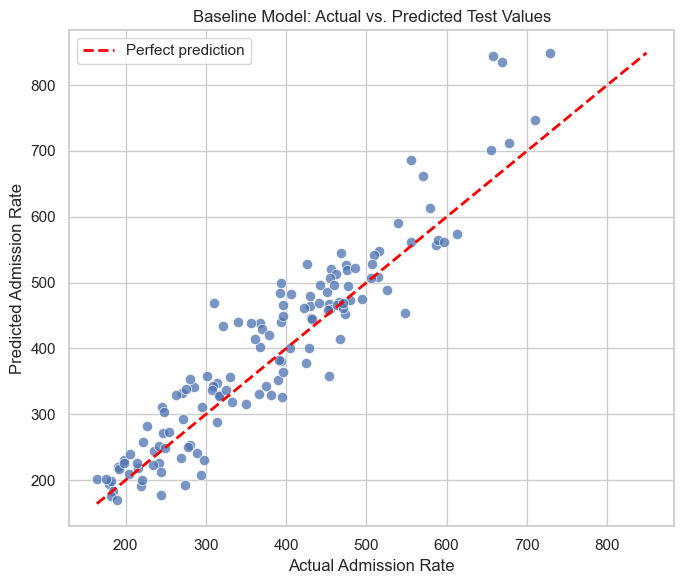

In [16]:
# actual vs predicted test values


plt.figure(
    figsize=(7, 6)
)

sns.scatterplot(
    x=y_test.values,
    y=test_pred,
    s=55,
    alpha=0.75
)

min_val = min(
    y_test.min(),
    test_pred.min()
)

max_val = max(
    y_test.max(),
    test_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel(
    "Actual Admission Rate"
)

plt.ylabel(
    "Predicted Admission Rate"
)

plt.title(
    "Baseline Model: Actual vs. Predicted Test Values"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "baseline_actual_vs_predicted_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

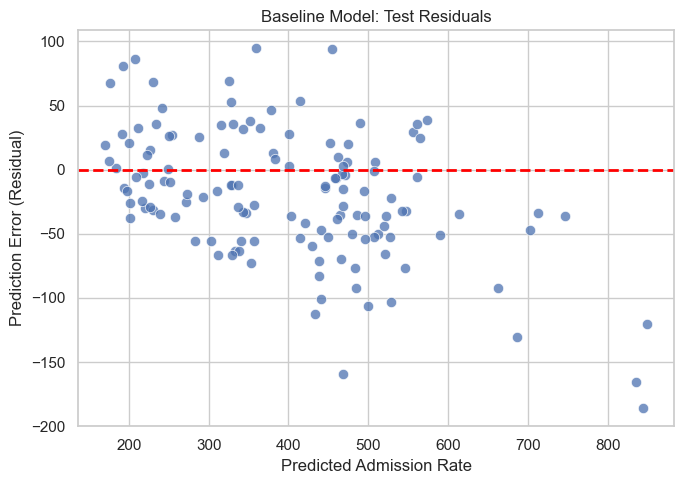

In [17]:
# test residual
test_residuals = (
    y_test.values
    - test_pred
)

plt.figure(
    figsize=(7, 5)
)

sns.scatterplot(
    x=test_pred,
    y=test_residuals,
    s=55,
    alpha=0.75
)

plt.axhline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Predicted Admission Rate"
)

plt.ylabel(
    "Prediction Error (Residual)"
)

plt.title(
    "Baseline Model: Test Residuals"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "baseline_test_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

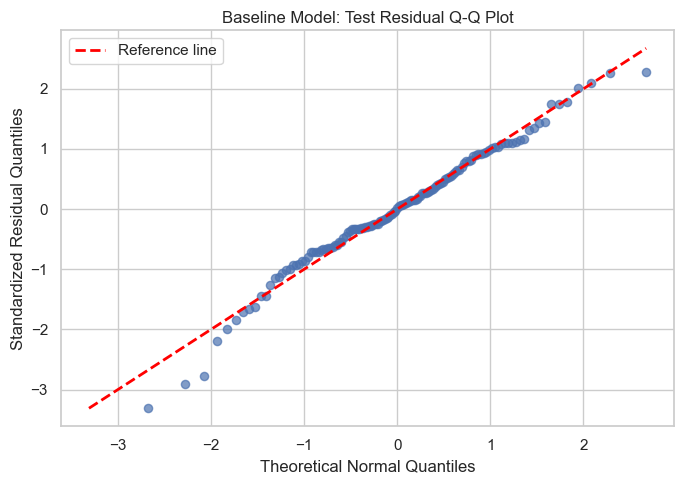

In [18]:
# test residual Q-Q 

sorted_test_residuals = np.sort(
    test_residuals
)

n_test = len(
    sorted_test_residuals
)

probabilities_test = (
    np.arange(1, n_test + 1) - 0.5
) / n_test

theoretical_test_quantiles = norm.ppf(
    probabilities_test
)

standardized_test_residuals = (
    sorted_test_residuals
    - np.mean(sorted_test_residuals)
) / np.std(sorted_test_residuals)

plt.figure(
    figsize=(7, 5)
)

plt.scatter(
    theoretical_test_quantiles,
    standardized_test_residuals,
    s=35,
    alpha=0.7
)

q_min = min(
    theoretical_test_quantiles.min(),
    standardized_test_residuals.min()
)

q_max = max(
    theoretical_test_quantiles.max(),
    standardized_test_residuals.max()
)

plt.plot(
    [q_min, q_max],
    [q_min, q_max],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Reference line"
)

plt.xlabel(
    "Theoretical Normal Quantiles"
)

plt.ylabel(
    "Standardized Residual Quantiles"
)

plt.title(
    "Baseline Model: Test Residual Q-Q Plot"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "baseline_test_residual_qq_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

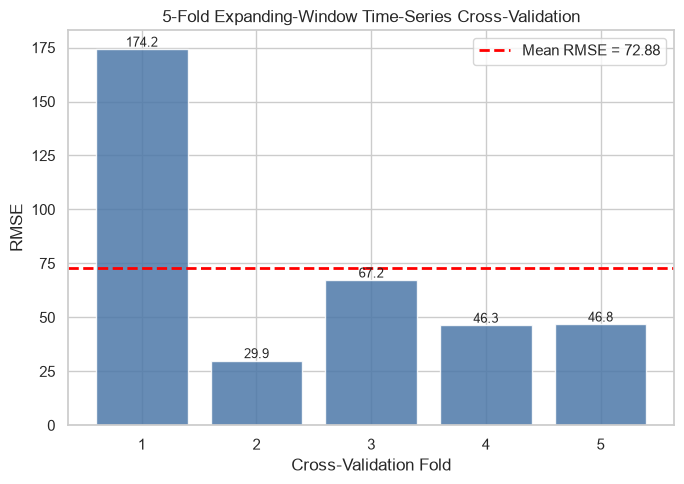

In [48]:
# time-series cross-validation RMSE plot


cv_folds = np.arange(
    1,
    len(cv_rmse) + 1
)

plt.figure(
    figsize=(7, 5)
)

bars = plt.bar(
    cv_folds,
    cv_rmse,
    color="#4C78A8",
    alpha=0.85
)

plt.axhline(
    cv_rmse.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean RMSE = {cv_rmse.mean():.2f}"
)

plt.xlabel(
    "Cross-Validation Fold"
)

plt.ylabel(
    "RMSE"
)

plt.title(
    "5-Fold Expanding-Window Time-Series Cross-Validation"
)

plt.xticks(
    cv_folds
)

plt.legend()

for bar, value in zip(
    bars,
    cv_rmse
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "baseline_time_series_cv_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
# save baseline  metrics

metrics = pd.DataFrame(
    {
        "Dataset": [
            "Train",
            "Test"
        ],

        "RMSE": [
            rmse(
                y_train.values,
                train_pred
            ),
            rmse(
                y_test.values,
                test_pred
            )
        ],

        "MAE": [
            mae(
                y_train.values,
                train_pred
            ),
            mae(
                y_test.values,
                test_pred
            )
        ],

        "R2": [
            r2_score_numpy(
                y_train.values,
                train_pred
            ),
            r2_score_numpy(
                y_test.values,
                test_pred
            )
        ]
    }
)

metrics.to_csv(
    DATA_DIR / "baseline_engineered_metrics.csv",
    index=False
)

coef.to_csv(
    DATA_DIR / "baseline_engineered_coefficients.csv",
    index=False
)

print("Saved:")
print(
    DATA_DIR / "baseline_engineered_metrics.csv"
)

print(
    DATA_DIR / "baseline_engineered_coefficients.csv"
)

Saved:
/Users/caseybrookshier/Team-Rho-Capstone-Project/Data/processed/Engineered_Data_v2/baseline_engineered_metrics.csv
/Users/caseybrookshier/Team-Rho-Capstone-Project/Data/processed/Engineered_Data_v2/baseline_engineered_coefficients.csv


In [50]:
# baseline data dictionary


train_current = pd.read_csv(
    TRAIN_FILE
)

test_current = pd.read_csv(
    TEST_FILE
)

all_data = pd.concat(
    [
        train_current.assign(
            _dataset="Training"
        ),
        test_current.assign(
            _dataset="Testing"
        )
    ],
    ignore_index=True
)

variable_descriptions = {
    "State":
        "U.S. state associated with the observation.",

    "Year":
        "Calendar year of the observation.",

    "admission_rate_per_100k":
        "Psychiatric admission rate per 100,000 population; model target.",

    "admission_rate_lag2":
        "Psychiatric admission rate from two years earlier.",

    "neighbor_admission_rate_lag1":
        "Previous-year psychiatric admission rate among neighboring states.",

    "search_PC1":
        "First principal component summarizing Google Trends search activity.",

    "search_PC2":
        "Second principal component summarizing Google Trends search activity.",

    "search_PC3":
        "Third principal component summarizing Google Trends search activity.",

    "log_state_population":
        "Natural-log-transformed state population."
}

dictionary_rows = []

for column in all_data.columns:

    if column == "_dataset":
        continue

    series = all_data[column]

    if pd.api.types.is_numeric_dtype(series):

        min_value = series.min()
        max_value = series.max()
        mean_value = series.mean()

        range_text = (
            f"{min_value:.4f} to {max_value:.4f}"
        )

        mean_text = (
            f"{mean_value:.4f}"
        )

    else:

        min_value = ""
        max_value = ""
        mean_text = ""

        if series.nunique(
            dropna=True
        ) <= 10:

            range_text = ", ".join(
                map(
                    str,
                    sorted(
                        series
                        .dropna()
                        .unique()
                    )
                )
            )

        else:

            range_text = (
                f"{series.nunique(dropna=True)} "
                "unique values"
            )

    dictionary_rows.append(
        {
            "Variable": column,

            "Description":
                variable_descriptions.get(
                    column,
                    "Engineered predictor; "
                    "see preprocessing documentation."
                ),

            "Data Type":
                str(series.dtype),

            "Non-Missing":
                int(series.notna().sum()),

            "Missing":
                int(series.isna().sum()),

            "Unique Values":
                int(series.nunique(dropna=True)),

            "Range / Categories":
                range_text,

            "Mean (numeric)":
                mean_text
        }
    )

data_dictionary = pd.DataFrame(
    dictionary_rows
)

data_dictionary.to_csv(
    DATA_DIR / "baseline_data_dictionary.csv",
    index=False
)

data_dictionary.to_html(
    DATA_DIR / "baseline_data_dictionary.html",
    index=False,
    border=0
)

print(
    "Data dictionary saved."
)

Data dictionary saved.


In [51]:
# =save baseline metrics


report_metrics = pd.DataFrame(
    {
        "Metric": [
            "Training observations",
            "Testing observations",
            "Number of predictors",
            "Training RMSE",
            "Training MAE",
            "Training R²",
            "Testing RMSE",
            "Testing MAE",
            "Testing R²",
            "CV mean RMSE",
            "CV RMSE standard deviation",
            "Training residual mean",
            "Training Durbin-Watson"
        ],

        "Value": [
            len(train_current),
            len(test_current),
            X_train.shape[1],

            rmse(
                y_train.values,
                train_pred
            ),

            mae(
                y_train.values,
                train_pred
            ),

            r2_score_numpy(
                y_train.values,
                train_pred
            ),

            rmse(
                y_test.values,
                test_pred
            ),

            mae(
                y_test.values,
                test_pred
            ),

            r2_score_numpy(
                y_test.values,
                test_pred
            ),

            cv_rmse.mean(),
            cv_rmse.std(),

            residuals.mean(),

            durbin_watson_numpy(
                residuals
            )
        ]
    }
)

report_metrics.to_csv(
    DATA_DIR / "baseline_report_metrics.csv",
    index=False
)

print(
    "Report metrics saved:"
)

print(
    DATA_DIR / "baseline_report_metrics.csv"
)

Report metrics saved:
/Users/caseybrookshier/Team-Rho-Capstone-Project/Data/processed/Engineered_Data_v2/baseline_report_metrics.csv


In [52]:
# confirm baseline outputs

print("\n========================================")
print("BASELINE OUTPUTS")
print("========================================")

print("\nFigures:")

for file in sorted(FIGURE_DIR.glob("*")):
    print(" ", file.name)

print("\nData/report files:")

for filename in [
    "baseline_engineered_metrics.csv",
    "baseline_engineered_coefficients.csv",
    "baseline_data_dictionary.csv",
    "baseline_data_dictionary.html",
    "baseline_report_metrics.csv"
]:
    path = DATA_DIR / filename

    if path.exists():
        print(" ", path.name)
    else:
        print("  MISSING:", path.name)

print("\nBaseline notebook completed successfully.")
print("Project root:", PROJECT_ROOT)
print("Figures:", FIGURE_DIR)
print("Data:", DATA_DIR)


BASELINE OUTPUTS

Figures:
  baseline_actual_vs_predicted_test.png
  baseline_test_residual_plot.png
  baseline_test_residual_qq_plot.png
  baseline_time_series_cv_rmse.png
  baseline_training_residual_plot.png
  baseline_training_residual_qq_plot.png

Data/report files:
  baseline_engineered_metrics.csv
  baseline_engineered_coefficients.csv
  baseline_data_dictionary.csv
  baseline_data_dictionary.html
  baseline_report_metrics.csv

Baseline notebook completed successfully.
Project root: /Users/caseybrookshier/Team-Rho-Capstone-Project
Figures: /Users/caseybrookshier/Team-Rho-Capstone-Project/figures/baseline
Data: /Users/caseybrookshier/Team-Rho-Capstone-Project/Data/processed/Engineered_Data_v2


In [53]:
# baseline summary


print(
    f"""
Team Rho Baseline Model
=======================

Repository:
{PROJECT_ROOT}

Training data:
{TRAIN_FILE}

Testing data:
{TEST_FILE}

Baseline figures:
{FIGURE_DIR}

Training observations: {len(train_current)}
Testing observations:  {len(test_current)}

Predictors: {X_train.shape[1]}

Training RMSE: {rmse(y_train.values, train_pred):.3f}
Training MAE:  {mae(y_train.values, train_pred):.3f}
Training R²:   {r2_score_numpy(y_train.values, train_pred):.3f}

Testing RMSE:  {rmse(y_test.values, test_pred):.3f}
Testing MAE:   {mae(y_test.values, test_pred):.3f}
Testing R²:    {r2_score_numpy(y_test.values, test_pred):.3f}

Mean CV RMSE:  {cv_rmse.mean():.3f}
CV RMSE SD:    {cv_rmse.std():.3f}

"""
)


Team Rho Baseline Model

Repository:
/Users/caseybrookshier/Team-Rho-Capstone-Project

Training data:
/Users/caseybrookshier/Team-Rho-Capstone-Project/Data/processed/Engineered_Data_v2/team_rho_train_preprocessed_engineered_v2.csv

Testing data:
/Users/caseybrookshier/Team-Rho-Capstone-Project/Data/processed/Engineered_Data_v2/team_rho_test_preprocessed_engineered_v2.csv

Baseline figures:
/Users/caseybrookshier/Team-Rho-Capstone-Project/figures/baseline

Training observations: 227
Testing observations:  133

Predictors: 51

Training RMSE: 38.035
Training MAE:  23.614
Training R²:   0.936

Testing RMSE:  53.983
Testing MAE:   41.966
Testing R²:    0.829

Mean CV RMSE:  72.881
CV RMSE SD:    52.031


